In [1]:
# Teste de Conhecimento 1 - Fundamentos Matemáticos

## Análise e previsão dos custos de transporte
# Aluno: Isaac Oliveira

# Uma empresa de comércio eletrônico registrou seus custos mensais de transporte durante 12 meses.
# Neste notebook os dados são analisados com uma função afim f(x) = ax + b, que é usada para
# representar a tendência dos custos e prever os valores dos meses 13, 14 e 15.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MultipleLocator


def num(valor, casas=2):
    # Formata números no padrão brasileiro (ex.: 1.791,61)
    return f"{valor:,.{casas}f}".replace(",", "X").replace(".", ",").replace("X", ".")


def reais(valor, casas=2):
    return "R$ " + num(valor, casas)


# Eixo y dos gráficos em reais (R$ 50.000)
eixo_reais = FuncFormatter(lambda valor, _: reais(valor, 0))

In [3]:
## Etapa 1 - Carregar os dados

dados = pd.read_csv("base_custos_transporte.csv")

print("Quantidade de meses na base:", len(dados))
dados

Quantidade de meses na base: 12


,mes,custo_transporte
0,1,44500
1,2,45200
2,3,48300
3,4,48600
4,5,51300
5,6,53300
6,7,53800
7,8,57000
8,9,57900
9,10,61000


In [4]:
## Etapa 2 - Identificar as variáveis

### a) Qual é a variável independente?
# O mês (coluna "mes"). É a variável de entrada: escolhemos o mês que queremos analisar e o seu
# valor não depende do custo, o tempo passa de qualquer forma.

### b) Qual é a variável dependente?
# O custo de transporte (coluna "custo_transporte"). O seu valor depende do mês em que é medido e,
# para cada mês, existe um único custo. Por isso o custo pode ser escrito como função do mês: y = f(x).

### c) O que representa cada variável no contexto do problema?
# mes (x): a posição do mês na sequência dos 12 meses registrados (1 = primeiro mês, 12 = último).
# custo_transporte (y): o total que a empresa gastou com transporte (entregas e fretes) naquele mês, em reais.

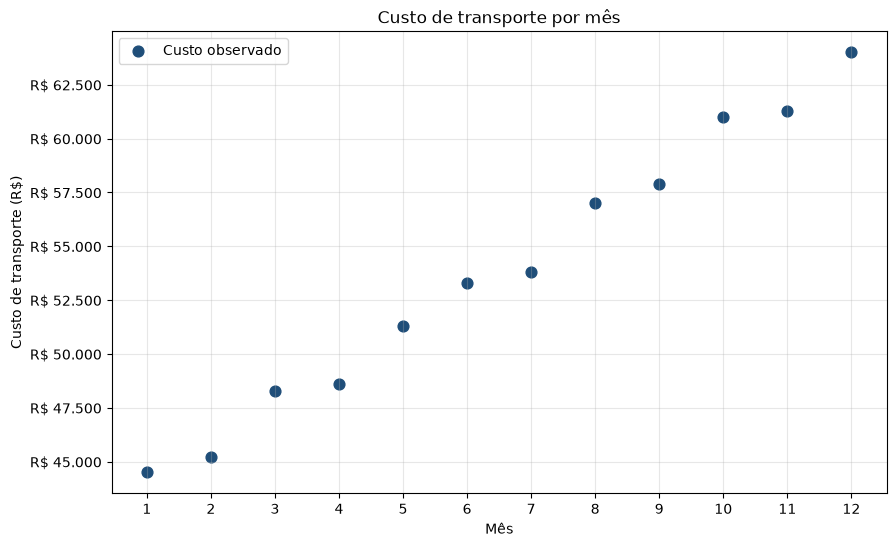

Aumento de um mês para o outro (R$): [700, 3100, 300, 2700, 2000, 500, 3200, 900, 3100, 300, 2700]


In [5]:
## Etapa 3 - Construir um gráfico

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(dados["mes"], dados["custo_transporte"], color="#1f4e79", s=60, label="Custo observado")

ax.set_title("Custo de transporte por mês")
ax.set_xlabel("Mês")
ax.set_ylabel("Custo de transporte (R$)")
ax.xaxis.set_major_locator(MultipleLocator(1))
ax.yaxis.set_major_formatter(eixo_reais)
ax.grid(alpha=0.3)
ax.legend()
plt.show()

# Quanto o custo mudou de um mês para o seguinte
variacao = dados["custo_transporte"].diff().dropna()
print("Aumento de um mês para o outro (R$):", list(variacao.astype(int)))

### Comportamento observado
# O custo sobe em todos os meses, sem nenhuma queda: passa de R$ 44.500 no mês 1 para R$ 64.000 no
# mês 12, um aumento de R$ 19.500 (cerca de 43,8%) no período.
# Os pontos ficam aproximadamente alinhados em uma reta inclinada para cima, o que indica um
# crescimento em ritmo quase constante e sugere o uso de uma função afim.
# O aumento não é igual todo mês: há meses de alta forte (até R$ 3.200) e meses quase estáveis
# (R$ 300), em geral alternados, formando um leve "zigue-zague" em torno da tendência de alta.

In [6]:
## Etapa 4 - Encontrar uma função

# Função afim: f(x) = ax + b, com x = mês e y = custo de transporte.
# Como os pontos não estão exatamente sobre uma reta, foi usado o método dos mínimos quadrados, que
# encontra a reta com a menor soma dos erros ao quadrado. As fórmulas usam apenas médias e somatórios:
#   a = Σ(x - x̄)(y - ȳ) / Σ(x - x̄)²
#   b = ȳ - a · x̄

x = dados["mes"]
y = dados["custo_transporte"]

media_x = x.mean()
media_y = y.mean()

soma_produtos = ((x - media_x) * (y - media_y)).sum()
soma_quadrados = ((x - media_x) ** 2).sum()

a = soma_produtos / soma_quadrados
b = media_y - a * media_x

print(f"x̄ = {num(media_x, 1)}")
print(f"ȳ = {num(media_y)}")
print(f"Σ(x - x̄)(y - ȳ) = {num(soma_produtos)}")
print(f"Σ(x - x̄)² = {num(soma_quadrados)}")
print()
print(f"a = {num(soma_produtos)} / {num(soma_quadrados)} = {num(a, 4)}")
print(f"b = {num(media_y)} - {num(a, 4)} × {num(media_x, 1)} = {num(b, 4)}")

# Arredondando os coeficientes para centavos
a = round(a, 2)
b = round(b, 2)


def f(mes):
    return a * mes + b


print()
print(f"a = {num(a)}")
print(f"b = {num(b)}")
print(f"Função encontrada: f(x) = {num(a)}x + {num(b)}")

# Conferência com o ajuste de grau 1 do numpy
print("\nConferência com np.polyfit (a, b):", np.polyfit(x, y, 1).round(4))

x̄ = 6,5
ȳ = 53.850,00
Σ(x - x̄)(y - ȳ) = 256.200,00
Σ(x - x̄)² = 143,00

a = 256.200,00 / 143,00 = 1.791,6084
b = 53.850,00 - 1.791,6084 × 6,5 = 42.204,5455

a = 1.791,61
b = 42.204,55
Função encontrada: f(x) = 1.791,61x + 42.204,55

Conferência com np.polyfit (a, b): [ 1791.6084 42204.5455]


In [7]:
## Etapa 5 - Interpretar a função

# Função encontrada: f(x) = 1.791,61x + 42.204,55

### a) O que representa o coeficiente a no contexto do problema?
# a = 1.791,61 é a taxa de variação (inclinação da reta): quanto o custo muda quando se avança um mês.
# Ou seja, o custo de transporte aumenta, em média, cerca de R$ 1.791,61 por mês.

### b) O que representa o coeficiente b?
# b = 42.204,55 é o valor da função quando x = 0, ou seja, f(0) = b. Seria o custo estimado para um
# "mês 0", anterior ao início dos registros, e funciona como ponto de partida da reta. Não é um custo
# observado, e sim um valor projetado pela função, menor que o custo real do mês 1 (R$ 44.500).

### c) O valor de a indica crescimento ou redução dos custos?
# Crescimento. Como a > 0, a função é crescente: quanto maior o mês, maior o custo estimado.
# Se a fosse negativo, a reta desceria e indicaria redução dos custos.

print(f"f(0) = {reais(f(0))}  -> igual a b")
print(f"f(2) - f(1) = {reais(f(2) - f(1))}  -> igual a a")

f(0) = R$ 42.204,55  -> igual a b
f(2) - f(1) = R$ 1.791,61  -> igual a a


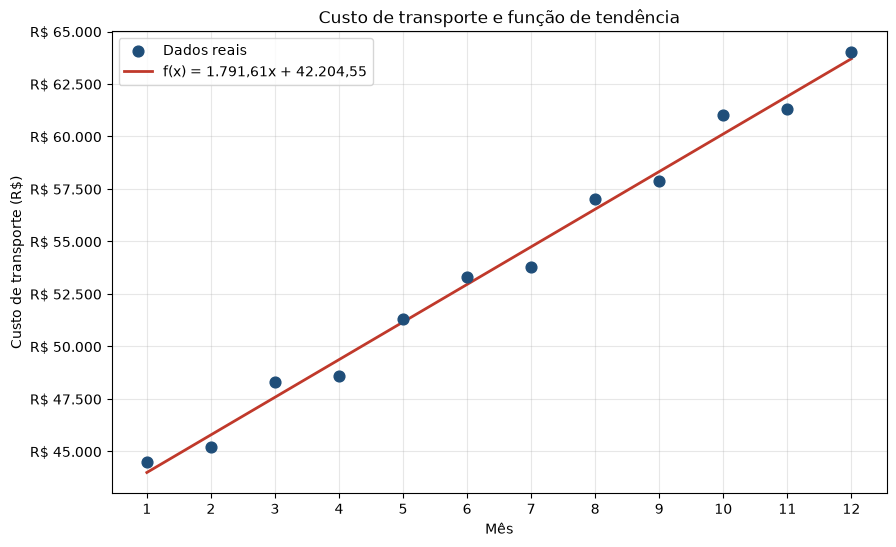

In [8]:
## Etapa 6 - Representar a função graficamente

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(x, y, color="#1f4e79", s=60, zorder=3, label="Dados reais")
ax.plot([1, 12], [f(1), f(12)], color="#c0392b", linewidth=2, label=f"f(x) = {num(a)}x + {num(b)}")

ax.set_title("Custo de transporte e função de tendência")
ax.set_xlabel("Mês")
ax.set_ylabel("Custo de transporte (R$)")
ax.xaxis.set_major_locator(MultipleLocator(1))
ax.yaxis.set_major_formatter(eixo_reais)
ax.grid(alpha=0.3)
ax.legend()
plt.show()

### Análise do gráfico
# A reta passa pelo meio dos pontos: alguns meses ficam um pouco acima e outros um pouco abaixo dela,
# sempre próximos. A inclinação positiva mostra a tendência de alta dos custos ao longo do tempo.

In [9]:
## Etapa 7 - Fazer previsões

# Substituindo x = 13, 14 e 15 na função f(x) = 1.791,61x + 42.204,55:

for mes in [13, 14, 15]:
    print(f"f({mes}) = {num(a)} × {mes} + {num(b)} = {num(a * mes)} + {num(b)} = {reais(f(mes))}")

# Cada previsão é a anterior somada a a (R$ 1.791,61), porque a função cresce sempre no mesmo ritmo.

f(13) = 1.791,61 × 13 + 42.204,55 = 23.290,93 + 42.204,55 = R$ 65.495,48
f(14) = 1.791,61 × 14 + 42.204,55 = 25.082,54 + 42.204,55 = R$ 67.287,09
f(15) = 1.791,61 × 15 + 42.204,55 = 26.874,15 + 42.204,55 = R$ 69.078,70


In [10]:
## Etapa 8 - Analisar o resultado

# Comparação entre o custo real e o valor da função nos últimos meses observados

for mes in [10, 11, 12]:
    real = dados.loc[dados["mes"] == mes, "custo_transporte"].iloc[0]
    diferenca = real - f(mes)
    print(f"Mês {mes}: real = {reais(real)} | função = {reais(f(mes))} | "
          f"diferença = {reais(diferenca)} ({num(diferenca / real * 100)}%)")

### a) A função encontrada representa bem a tendência dos dados?
# Sim. Nos meses 10, 11 e 12 a diferença entre o custo real e a função foi de no máximo R$ 879,35
# (1,44%). O valor real ficou ora acima (meses 10 e 12), ora abaixo (mês 11) da reta, então a função
# acompanha a tendência dos dados, mesmo sem acertar exatamente o valor de cada mês.

### b) Os custos estão aumentando ou diminuindo?
# Aumentando. O coeficiente a é positivo, o custo não caiu em nenhum dos 12 meses e as previsões para
# os meses 13 a 15 (de R$ 65.495,48 a R$ 69.078,70) continuam acima do último valor real (R$ 64.000).

### c) Aproximadamente quanto o custo aumenta a cada mês?
# Cerca de R$ 1.791,61 por mês, que é o valor do coeficiente a. A conta com o primeiro e o último mês,
# (64.000 - 44.500) / 11 ≈ R$ 1.772,73, dá um valor próximo e confirma a ordem de grandeza.

Mês 10: real = R$ 61.000,00 | função = R$ 60.120,65 | diferença = R$ 879,35 (1,44%)
Mês 11: real = R$ 61.300,00 | função = R$ 61.912,26 | diferença = R$ -612,26 (-1,00%)
Mês 12: real = R$ 64.000,00 | função = R$ 63.703,87 | diferença = R$ 296,13 (0,46%)


In [11]:
## Etapa 9 - Conclusão

# Com base nos dados analisados, a empresa pode esperar que os custos de transporte continuem subindo
# nos próximos meses, em torno de R$ 1.800 por mês. Pela função f(x) = 1.791,61x + 42.204,55, o custo
# deve chegar a aproximadamente R$ 65.495 no mês 13, R$ 67.287 no mês 14 e R$ 69.079 no mês 15.
# A função acompanhou bem os dados (nos últimos meses a diferença não passou de 1,44%), mas o valor
# real de cada mês pode ficar um pouco acima ou abaixo da previsão, como aconteceu nos meses observados.
# Por isso, a empresa deve se planejar para um orçamento de transporte maior e recalcular a função
# conforme novos meses forem registrados, já que a previsão é mais confiável no curto prazo.